In [8]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
pd.set_option("display.max_columns", None)

if os.getenv("KAGGLE_KERNEL_RUN_TYPE"):
    ENV = "kaggle"
    DATA_DIR = Path("/kaggle/input/competitions/playground-series-s6e3")
    ORIG_DIR = Path("/kaggle/input/datasets/cdeotte/s6e3-original-dataset")
else:
    ENV = "local"
    DATA_DIR = Path("./data/")
    ORIG_DIR = DATA_DIR
print(f"Environment: {ENV}")
train = pd.read_csv(DATA_DIR/"train.csv").drop("id", axis=1)
test = pd.read_csv(DATA_DIR/"test.csv").drop("id", axis=1)
orig_fn = "original.csv" if ENV == "local" else "WA_Fn-UseC_-Telco-Customer-Churn.csv"
original = pd.read_csv(DATA_DIR/orig_fn).drop("customerID", axis=1)
sub = pd.read_csv(DATA_DIR/"sample_submission.csv")
print("Data Loaded")

Environment: local
Data Loaded


In [12]:
display(f"Train shape: {train.shape}")
display(train.head(3))
display(f"Test shape: {test.shape}")
display(test.head(3))
display(f"Original shape: {original.shape}")
display(original.head(3))

'Train shape: (594194, 20)'

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,No


'Test shape: (254655, 19)'

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55


'Original shape: (7043, 20)'

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## Preprocessing steps

- Encode the target variable `Churn`
- Convert `SeniorCitizen` to object type to work with scikit-learn pipeline and exploratory vizualization
- Convert `TotalCharges` in the original dataset to a number.
- Fix `TotalCharges` empty string with zeros (rows with `tenure == 0`)

In [14]:
for df in (train, original):
    df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [15]:
for df in (train, test, original):
    df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

In [18]:
original["TotalCharges"] = pd.to_numeric(original["TotalCharges"], errors="coerce")
original.loc[original["tenure"]==0, "TotalCharges"] = 0

### Constant variables

In [21]:
TARGET = "Churn"
CATS = test.select_dtypes(include="object").columns.tolist()
NUMS = test.select_dtypes(include="number").columns.tolist()
DSEED = 10431053

In [29]:
train.Churn.mean()/ (1- train.Churn.mean())

np.float64(0.29066830011056155)

## Target - Churn

The minority class ratio is around 29%. Mild imbalance; most models will handle it without many problems.

What's more interesting is the ~4pp distribution shift between train and original datasets, probably from the synthetic generation. If we extract target-encoded features from the original dataset, the slightly different base rate suggests using smoothed/regularized encodings. Otherwise, we will be injecting a biased prior, telling the model a rate that's systematically too high because it was computed under a different class distribution. 

In [32]:
mcr = train.Churn.mean()/ (1- train.Churn.mean()) * 100
print(f"Minority class ratio: {mcr:.2f}%")

Minority class ratio: 29.07%


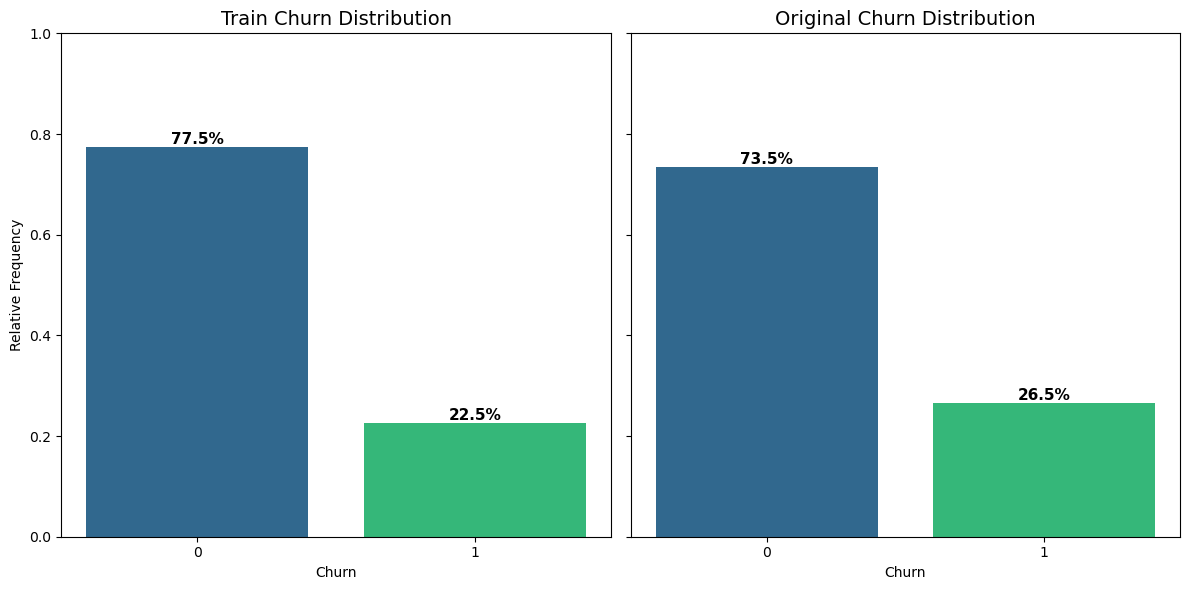

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for ax, (name, df) in zip(axes, [("Train", train), ("Original", original)]):
    counts = df[TARGET].value_counts(normalize=True).sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values, color=sns.color_palette("viridis", 2))
    ax.set_title(f"{name} Churn Distribution", fontsize=14)
    ax.set_ylabel("Relative Frequency" if ax == axes[0] else "")
    ax.set_xlabel("Churn")
    ax.set_ylim(0, 1.0)
    for bar, val in zip(bars, counts.values):
        ax.annotate(f'{val:.1%}', (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()